# Background

## Urban Profile: Hat Yai, Thailand

Hat Yai is the economic and logistical heart of Southern Thailand. With a city proper population of 243,778 and a broader metropolitan area housing nearly 800,000 residents, it stands as the region's largest urban center. Strategically located near the Malaysian border, Hat Yai serves as the primary funnel for cross-border trade and the critical junction for both the Southern Railway and the Asian Highway. However, this role as a regional transit hub has created significant strain on local infrastructure. According to the TomTom Traffic Index(2024), Hat Yai ranks as the #1 most congested city in Thailand (based on travel time per 10km). This high baseline congestion indicates that the city's transportation network is already operating at critical capacity, leaving little buffer for disruptions even before disaster strikes.

In [59]:
import warnings


warnings.filterwarnings("ignore", category=FutureWarning)

# study area - Hat Yai
import folium
import geopandas as gpd

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
thailand= world[world['name'] == "Thailand"]

hat_yai_coords = [7.006, 100.46]
thailand_center = [13.0, 101.0]

# interactive map of study area
m = folium.Map(location=thailand_center, zoom_start=6, tiles='OpenStreetMap')

folium.GeoJson(
    thailand,
   style_function=lambda feature: {
    'fillColor': '#f5a34c',  
    'color': '#f28a1b',      
    'weight': 2,
    'fillOpacity': 0.3,
    },
    name="Thailand Highlight"
).add_to(m)

# Marker for Hat Yai
folium.Marker(
    location=hat_yai_coords,
    popup="<b>Hat Yai</b><br>Major City in Southern Thailand", 
    tooltip="Hat Yai (Study Area)", 
    icon=folium.Icon(color='orange', icon='info-sign') 
).add_to(m)

from folium.plugins import MiniMap
minimap = MiniMap(toggle_display=True)
m.add_child(minimap)

m

## Flood Vulnerability：A Basin Under Pressure
The Digital Elevation Model (DEM) vividly illustrates Hat Yai's precarious position: the city sits in the bottom of the Khlong U-Taphao Basin, a topographic depression surrounded by steep mountain ranges. This "bowl-like" geometry creates a natural funnel, where rapid runoff from upstream highlands converges violently into the flat urban core, leaving water with nowhere to go.

This geographic trap is activated by the region's intense climate. Situated on the Thai-Malay peninsula, Hat Yai is directly exposed to the Northeast Monsoon, which brings torrential rainfall between November and January. Historically, extreme precipitation event， such as the massive storms in 2000 and 2010 have easily overwhelmed the city's drainage capacity. Despite heavy investments in structural defenses (canals and levees), the recurrence of flooding proves that current water management strategies are insufficient to handle the combined force of monsoonal volume, upstream deforestation, and the city's natural basin topography.

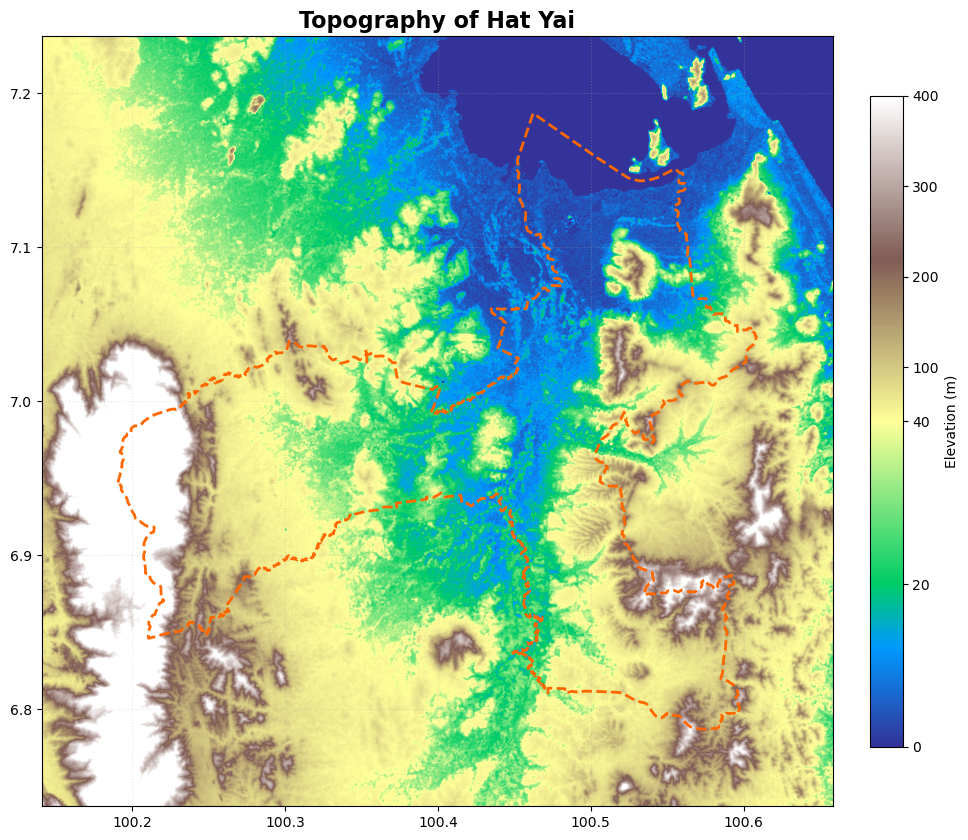

In [ ]:
import rasterio
from rasterio.merge import merge
import matplotlib.pyplot as plt
import matplotlib.colors as colors  
import numpy as np
import geopandas as gpd
import os
import osmnx as ox

# prepare boundary map
hat_yai_city = ox.geocode_to_gdf("Hat Yai, Songkhla, Thailand") 
hat_yai_city = hat_yai_city.to_crs(epsg=32647)
# hat_yai_city.to_file("data/hat_yai_city.shp")

files_to_mosaic = ["data/N07E100.hgt", "data/N06E100.hgt"]

src_files_to_mosaic = []
for fp in files_to_mosaic:
    if os.path.exists(fp):
        src = rasterio.open(fp)
        src_files_to_mosaic.append(src)

if src_files_to_mosaic:
    mosaic, out_trans = merge(src_files_to_mosaic)
    
    height, width = mosaic[0].shape
    west = out_trans[2]
    north = out_trans[5]
    east = west + (width * out_trans[0])
    south = north + (height * out_trans[4])

    fig, ax = plt.subplots(figsize=(12, 10))


    mosaic_clean = np.where(mosaic[0] < -100, np.nan, mosaic[0])
    divnorm = colors.TwoSlopeNorm(vmin=0, vcenter=40, vmax=400)

    img = ax.imshow(mosaic_clean, 
                    cmap='terrain', 
                    norm=divnorm, 
                    extent=[west, east, south, north])

    try:
        hat_yai_city = gpd.read_file("data/hat_yai_city.shp")
        city_wgs84 = hat_yai_city.to_crs(epsg=4326)
        
        city_wgs84.plot(ax=ax, facecolor='none', edgecolor='#FF6700', 
                        linewidth=2, linestyle='--', label='Urban Boundary')
        

        minx, miny, maxx, maxy = city_wgs84.total_bounds
        margin = 0.05 
        ax.set_xlim(minx - margin, maxx + margin)
        ax.set_ylim(miny - margin, maxy + margin)

    except:
        ax.set_xlim(100.35, 100.65)
        ax.set_ylim(6.90, 7.15)

    plt.title("Topography of Hat Yai", fontsize=16, fontweight='bold')

    cbar = plt.colorbar(img, ax=ax, fraction=0.035, pad=0.04, 
                        ticks=[0, 20, 40, 100, 200, 300, 400]) 
    cbar.set_label('Elevation (m)')
    
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.axis('on') 
    
    plt.show()
else:
    print("Nodata")
    
    
# output_path = "data/hat_yai_dem_filled.tif"

# out_meta = src.meta.copy()

# out_meta.update({
#     "driver": "GTiff",
#     "height": mosaic.shape[1],
#     "width": mosaic.shape[2],
#     "transform": out_trans,
#     "crs": src.crs  
# })


# with rasterio.open(output_path, "w", **out_meta) as dest:
#     dest.write(mosaic)

### Historical Major Flood Events (1988–2010)

Hat Yai has experienced several major flood events, with the following historical figures recorded by the Department of Disaster Prevention and Mitigation (DDPM). These events serve as a critical baseline for understanding the city's long-term vulnerability and the escalating risk posed by urban development.


* **1988:** This marked the first major modern flood in Hat Yai, setting the stage for future disaster preparedness efforts.
* **2000:** Considered one of the most severe floods in the city’s history. It resulted in the greatest loss of life and the highest economic damage on record.
* **2010:** This event notably tested the city’s new water management systems, demonstrating that despite lower rainfall than 2000, its massive geographical extent confirmed the city’s increasing vulnerability to runoff.

| Year | Accumulated Rainfall (mm) | Key Impact Indicators | Lives Lost | Economic Damage (Baht) |
| :--- | :--- | :--- | :--- | :--- |
| **1988** | - | Estimated total damage was 4 billion baht. | - | 4 Billion+ |
| **2000** | 497 | Over 320 km² of land flooded. | 30 | 18 Billion+ |
| **2010** | 428 | Over 80% of the city flooded (affecting approx. 30,000 households). | - | 10 Billion+ |